# Machine Learning Fundamentals

This section introduces the fundamental concepts of machine learning and deep learning that form the foundation for our magnetic field prediction approach.

## Learning Objectives

After completing this notebook, you will understand:
- The historical context and evolution of neural networks
- Key concepts in deep learning architectures
- Computational requirements and enabling technologies
- Training considerations for deep learning models

## Historical Context

Although Deep Learning has gained a lot of importance in recent times, it has been in existence since 1940. The timeline shows key developments:

- **1940s**: First experiment with neural networks performed
- **1980s**: Algorithms to train deep networks developed
- **1990s**: First successful application of Convolutional Neural Networks (CNN/ConvNets) developed by Yann LeCun (LeNet)
- **2000s**: Computational resources and data availability increased dramatically
- **2010s**: Deep learning became mainstream with breakthrough applications

The most popular architectures from the 1990s (LeNet) were used to read zip codes, handwritten digits, etc. Their utilization for producing state-of-the-art results in more evolved fields such as computer vision, text analysis, and forecasting demanded computational memory and speed that were not available on mainframes until a few years ago.

## Key Enabling Factors

Several factors have contributed to the success of deep learning models today:

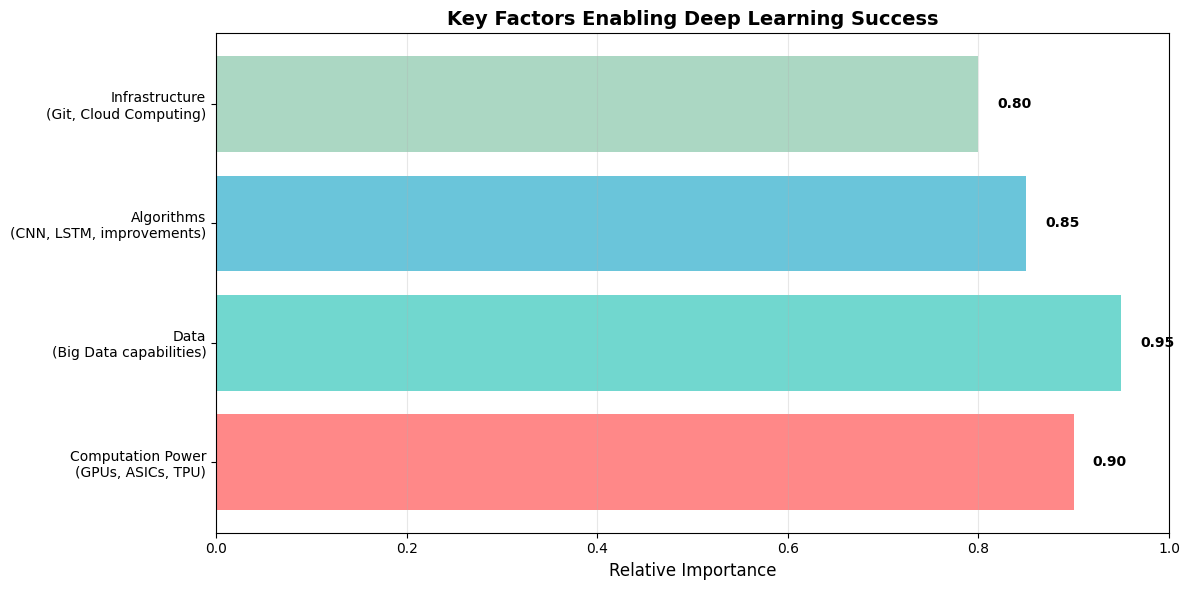

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Visualization of key enabling factors
factors = [
    'Computation Power\n(GPUs, ASICs, TPU)',
    'Data\n(Big Data capabilities)',
    'Algorithms\n(CNN, LSTM, improvements)',
    'Infrastructure\n(Git, Cloud Computing)'
]

importance = [0.9, 0.95, 0.85, 0.8]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(factors, importance, color=colors, alpha=0.8)

ax.set_xlim(0, 1)
ax.set_xlabel('Relative Importance', fontsize=12)
ax.set_title('Key Factors Enabling Deep Learning Success', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, imp) in enumerate(zip(bars, importance)):
    width = bar.get_width()
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{imp:.2f}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Deep Learning Evolution

The advancement in computational technologies and improvement in DL algorithms has been remarkable. The number of hidden units in artificial neural networks has doubled in size every 2-3 years since the late 2000s.

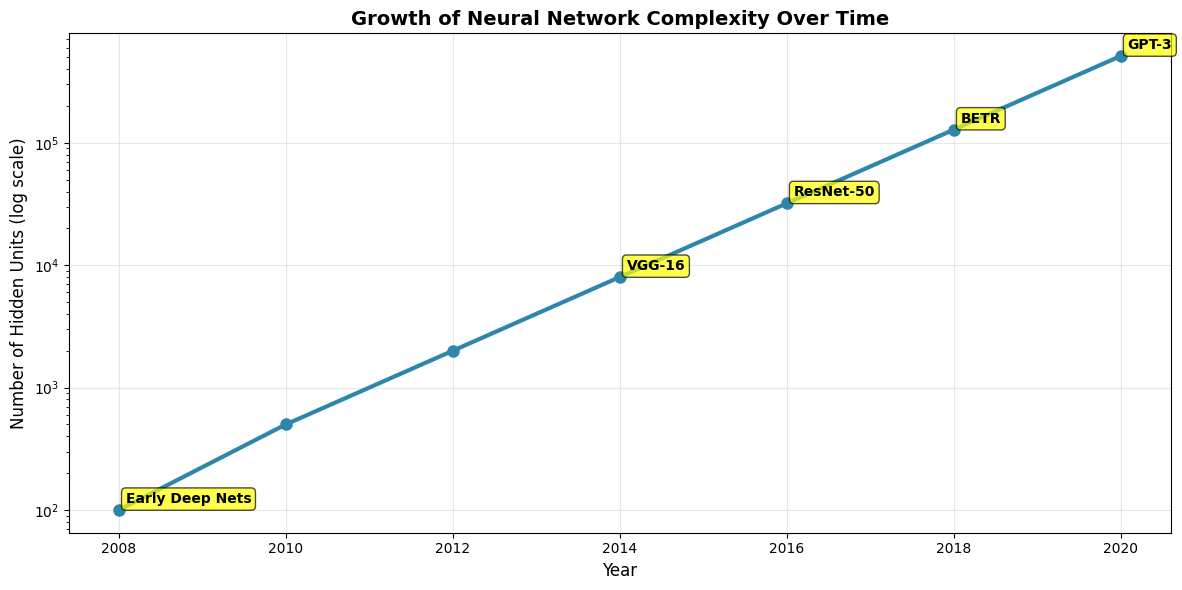

In [2]:
# Historical growth of neural network complexity
years = np.array([2008, 2010, 2012, 2014, 2016, 2018, 2020])
hidden_units = np.array([100, 500, 2000, 8000, 32000, 128000, 512000])
landmark_networks = ['Early Deep Nets', '', '', 'VGG-16', 'ResNet-50', 'BETR', 'GPT-3']

fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(years, hidden_units, 'o-', linewidth=3, markersize=8, color='#2E86AB')

# Add landmark annotations
for i, (year, units, network) in enumerate(zip(years, hidden_units, landmark_networks)):
    if network:  # Only label if there's a network name
        ax.annotate(network, (year, units), 
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Hidden Units (log scale)', fontsize=12)
ax.set_title('Growth of Neural Network Complexity Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(years)

plt.tight_layout()
plt.show()

## Defining Deep Networks

There is no universally agreed-upon threshold of depth dividing shallow learning from deep learning. Here are some historical perspectives:

- **Early Deep Networks** (2006): Three densely connected hidden layers
- **Very Deep Networks** (2014): VGG networks with 16+ hidden layers
- **Extremely Deep Networks** (2016): Residual networks with 50 to 1,000 hidden layers

For Feedforward Networks, CAP (Credit Assignment Path) is the chain of transformations from input to output. Most researchers agree that:
- **Deep Learning**: Multiple nonlinear layers (CAP ≥ 3)
- **Very Deep Learning**: CAP ≥ 10

So, a neural network with more than one hidden layer can be considered a Deep Network.

## When to Use Deep Neural Networks

Deep neural networks are particularly useful when:

### ✅ Ideal Use Cases
- **Complex Feature Interactions**: When the number of features increases and their interactions become too complicated for simpler models
- **Large Datasets**: When you have sufficient data to train complex models
- **Pattern Recognition**: Tasks involving image, text, or speech recognition
- **Non-linear Relationships**: When the underlying relationship is highly non-linear

### ⚠️ Considerations
- **Training Time**: Models take longer to train and become larger
- **Interpretability**: Complex models are harder to interpret
- **Hyperparameter Tuning**: Multiple configuration possibilities exist
- **Training Instability**: Training process can be sensitive to initial conditions

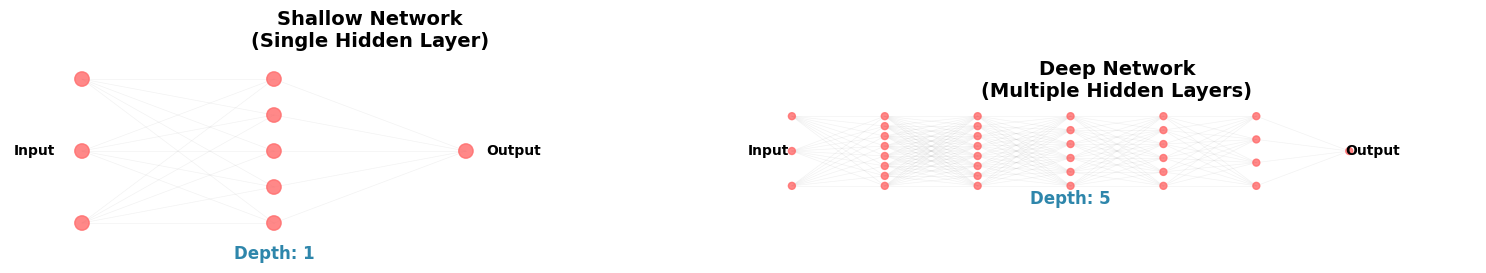

In [3]:
# Demonstration of deep vs shallow network complexity
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle

def draw_network_architecture(ax, depths, title):
    """Draw a neural network architecture diagram"""
    layers = [3] + depths + [1]  # Input + hidden + output
    n_layers = len(layers)
    
    # Calculate positions
    layer_spacing = 8
    max_neurons = max(layers)
    
    # Draw layers
    for i, n_neurons in enumerate(layers):
        x = i * layer_spacing
        
        # Position neurons evenly
        if n_neurons == 1:
            y_positions = [4]
        else:
            y_positions = np.linspace(1, 7, n_neurons)
        
        # Draw neurons
        for y in y_positions:
            circle = Circle((x, y), 0.3, color='#FF6B6B', alpha=0.8, zorder=3)
            ax.add_patch(circle)
        
        # Draw connections to next layer
        if i < n_layers - 1:
            next_x = (i + 1) * layer_spacing
            next_n_neurons = layers[i + 1]
            if next_n_neurons == 1:
                next_y_positions = [4]
            else:
                next_y_positions = np.linspace(1, 7, next_n_neurons)
            
            # Draw connections with transparency based on density
            for y1 in y_positions:
                for y2 in next_y_positions:
                    ax.plot([x, next_x], [y1, y2], 'gray', alpha=0.1, linewidth=0.5, zorder=1)
    
    # Labels
    ax.text(-2, 4, 'Input', fontsize=10, ha='center', va='center', fontweight='bold')
    ax.text((n_layers-1) * layer_spacing + 2, 4, 'Output', fontsize=10, ha='center', va='center', fontweight='bold')
    
    # Add depth indicator
    ax.text((n_layers-1) * layer_spacing / 2, -0.5, f'Depth: {len(depths)}', 
            fontsize=12, ha='center', fontweight='bold', color='#2E86AB')
    
    ax.set_xlim(-3, (n_layers) * layer_spacing + 3)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')

# Create comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

draw_network_architecture(ax1, [5], 'Shallow Network\n(Single Hidden Layer)')
draw_network_architecture(ax2, [8, 8, 6, 6, 4], 'Deep Network\n(Multiple Hidden Layers)')

plt.tight_layout()
plt.show()

## Training Considerations

The way a model is trained plays an essential role in its success and failure. Key factors include:

### Training Parameters
- **Starting Position**: Initial weight initialization
- **Optimization Algorithms**: Choice of optimizer (SGD, Adam, etc.)
- **Learning Rate**: Step size for parameter updates
- **Batch Size**: Number of samples per gradient update
- **Epochs**: Number of training iterations

### For Magnetic Field Prediction

For our specific application of magnetic field prediction:
- **Target/Label**: Magnetic field distribution (quantitative quality)
- **Features/Predictors**: Information related to geometric features, excitations, and material properties
- **Learning Type**: Supervised learning
- **Task Type**: Regression (predicting continuous field values)

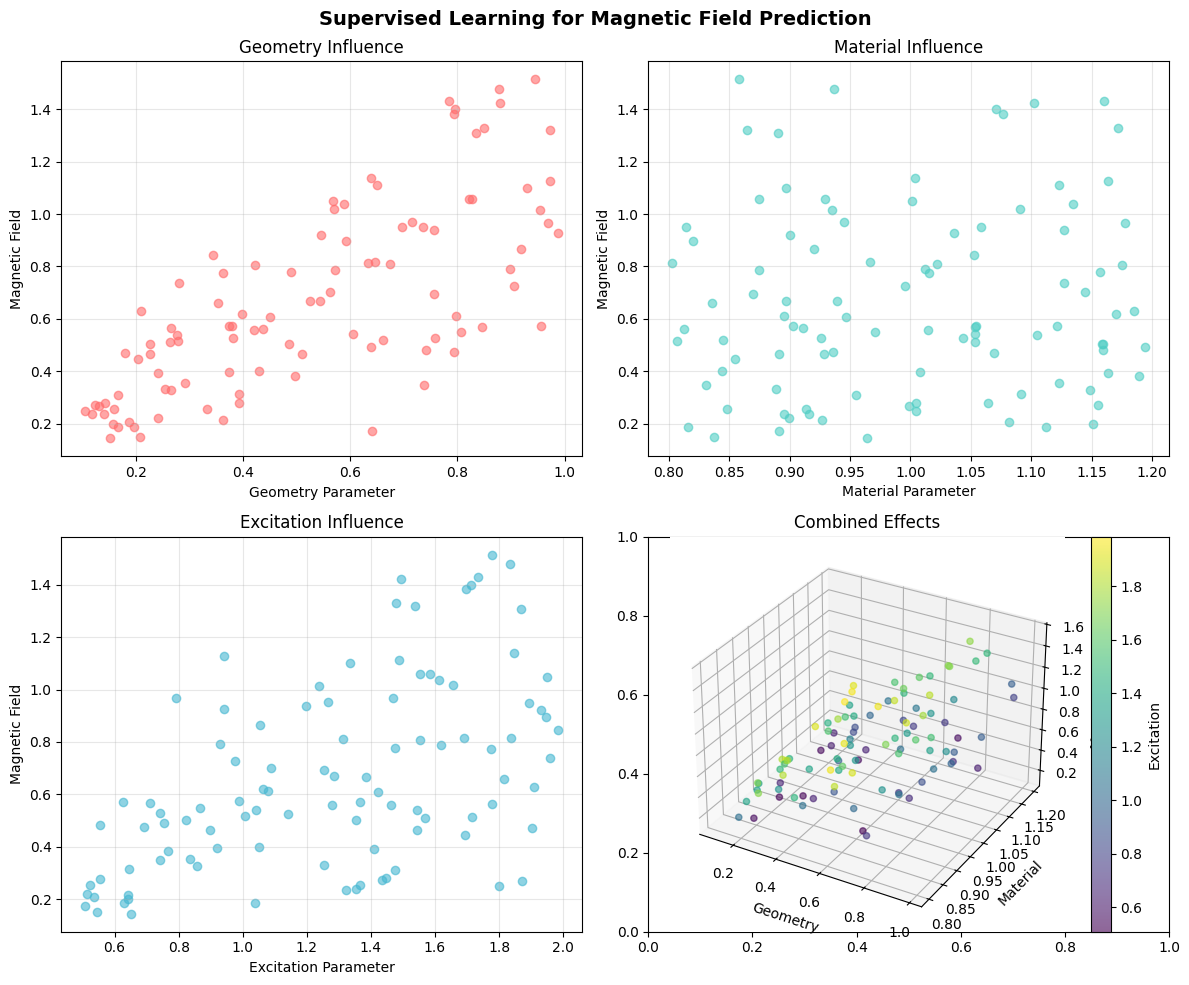

Key Insight: Deep learning models learn to map multiple input parameters
(geometry, material, excitation) to output magnetic field distributions.
This supervised learning approach uses labeled FEA data for training.


In [4]:
# Demonstration of supervised learning for field prediction
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Create synthetic example of input-output mapping
np.random.seed(42)

# Simulate input parameters (geometry, material, excitation)
n_samples = 100
geometry_param = np.random.uniform(0.1, 1.0, n_samples)  # Normalized geometry
material_param = np.random.uniform(0.8, 1.2, n_samples)  # Material property
excitation_param = np.random.uniform(0.5, 2.0, n_samples)  # Excitation level

# Simulate magnetic field output (simplified relationship)
field_output = (geometry_param * material_param * excitation_param + 
               0.1 * np.sin(2 * np.pi * geometry_param) + 
               0.05 * np.random.normal(0, 1, n_samples))

# Visualize the input-output relationship
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Supervised Learning for Magnetic Field Prediction', fontsize=14, fontweight='bold')

# Geometry vs Field
axes[0, 0].scatter(geometry_param, field_output, alpha=0.6, color='#FF6B6B')
axes[0, 0].set_xlabel('Geometry Parameter')
axes[0, 0].set_ylabel('Magnetic Field')
axes[0, 0].set_title('Geometry Influence')
axes[0, 0].grid(True, alpha=0.3)

# Material vs Field
axes[0, 1].scatter(material_param, field_output, alpha=0.6, color='#4ECDC4')
axes[0, 1].set_xlabel('Material Parameter')
axes[0, 1].set_ylabel('Magnetic Field')
axes[0, 1].set_title('Material Influence')
axes[0, 1].grid(True, alpha=0.3)

# Excitation vs Field
axes[1, 0].scatter(excitation_param, field_output, alpha=0.6, color='#45B7D1')
axes[1, 0].set_xlabel('Excitation Parameter')
axes[1, 0].set_ylabel('Magnetic Field')
axes[1, 0].set_title('Excitation Influence')
axes[1, 0].grid(True, alpha=0.3)

# 3D visualization of combined effect
from mpl_toolkits.mplot3d import Axes3D
ax_3d = fig.add_subplot(224, projection='3d')
scatter = ax_3d.scatter(geometry_param, material_param, field_output, 
                         c=excitation_param, cmap='viridis', alpha=0.6)
ax_3d.set_xlabel('Geometry')
ax_3d.set_ylabel('Material')
ax_3d.set_zlabel('Magnetic Field')
ax_3d.set_title('Combined Effects')
plt.colorbar(scatter, ax=ax_3d, label='Excitation')

plt.tight_layout()
plt.show()

print("Key Insight: Deep learning models learn to map multiple input parameters")
print("(geometry, material, excitation) to output magnetic field distributions.")
print("This supervised learning approach uses labeled FEA data for training.")

## Uncertainty Considerations

An important issue in supervised learning is that ML networks trained in a supervised manner could predict the solution for any arbitrary input. A DL emulator lacks physics-based judgment, which means:

### Challenges
- **Out-of-Distribution Inputs**: Network may predict unrealistic results for inputs far from training data
- **Overconfidence**: Networks can predict wrong results with high confidence
- **Physical Constraints**: May violate known physical laws or constraints

### Solutions
- **Uncertainty Quantification**: Provide confidence measures for predictions
- **Physics-Informed Learning**: Incorporate physical laws into the learning process
- **Validation Ranges**: Define valid input ranges and detect out-of-distribution samples

This chapter will address uncertainty analysis through Bayesian techniques to generalize the DL estimator and provide confidence measures for predictions.

## Key Takeaways

1. **Historical Context**: Deep learning has evolved from simple perceptrons to complex architectures over decades
2. **Enabling Technologies**: Computational power, big data, algorithms, and infrastructure made deep learning practical
3. **Network Depth**: Deep networks (CAP ≥ 3) can capture complex relationships that shallow networks cannot
4. **Training Complexity**: Multiple hyperparameters affect training success; careful tuning is required
5. **Application-Specific**: For magnetic field prediction, we use supervised regression with multiple input parameters
6. **Uncertainty Matters**: Confidence quantification is crucial for reliable deployment in engineering applications

Next, we'll explore how to collect and prepare the data needed for training these deep learning models.